In [1]:
!pip install kagglehub

In [2]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

## Project overview

This project investigates whether Steam game metadata and post-release engagement indicators can predict user reception.

The target variable is a Bayesian-smoothed review reception score derived from positive and negative Steam reviews. The smoothing step reduces instability for games with very few reviews.

The project is framed as a post-release reception prediction task, not as a pre-release success forecasting task, because several predictors such as estimated owners, playtime and Peak CCU are observed after release.

In [3]:
path = kagglehub.dataset_download("stefanotriscali/steam-database-2026-fixed")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'steam-database-2026-fixed' dataset.
Path to dataset files: /kaggle/input/steam-database-2026-fixed


In [4]:
games_df = pd.read_csv(path + "/steam_cleaned_2026.csv")
df = games_df.copy()

## Dataset loading and feature engineering

The dataset is based on a cleaned Steam games dataset. Several raw columns require preprocessing before modeling.

Release date is converted into numerical calendar features, while estimated owners are transformed from a range into a midpoint estimate. The current price and discount information are also used to reconstruct an approximate original price.

These transformations create a stable tabular representation suitable for supervised learning.

In [5]:
# Convert release date to numerical features

df["Release date"] = pd.to_datetime(games_df["Release date"], errors="coerce")

df["release_year"] = df["Release date"].dt.year
df["release_month"] = df["Release date"].dt.month

In [6]:
# Parse estimated owners range into midpoint

def parse_owners(x):
    try:
        low, high = x.replace(",", "").split("-")
        return (int(low) + int(high)) / 2
    except:
        return np.nan

df["owners_mid"] = df["Estimated owners"].apply(parse_owners)

In [7]:
# Reconstruct original price from current price and discount

if df["Discount"].max() > 1:
    df["discount_frac"] = df["Discount"] / 100
else:
    df["discount_frac"] = df["Discount"]

df["discount_frac"] = df["discount_frac"].clip(0, 0.99)

df["price_original"] = df["Price"] / (1 - df["discount_frac"])

df["price_original"] = df["price_original"].replace([np.inf, -np.inf], np.nan)

df["price_original"] = df["price_original"].fillna(df["Price"])

In [8]:
print("Shape:", df.shape)
display(df.head())

Shape: (114172, 43)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Publishers,Categories,Genres,Tags,Screenshots,release_year,release_month,owners_mid,discount_frac,price_original
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,2016,7,10000.0,0.65,14.971429
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,2019,5,10000.0,0.00,4.990000
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,2024,10,10000.0,0.00,8.990000
3,3631080,Maze Quest VR,2025-04-24,0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,2025,4,10000.0,0.00,4.990000
4,1654170,Agony VR,2023-04-05,0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,2023,4,10000.0,0.00,13.990000


In [9]:
cols_to_keep = [
    "AppID",
    "Name",
    "Positive",
    "Negative",
    "Recommendations",
    "price_original",
    "owners_mid",
    "Genres",
    "release_year",
    "release_month",
    "Average playtime forever",
    "Median playtime forever",
    "Peak CCU",
    "Categories",
    "Tags",
    "Developers",
    "Publishers"
]

df = df[cols_to_keep]

In [10]:
print("Missing values per column:\n", df.isna().sum())
display(df.describe())

Missing values per column:
 AppID                           0
Name                            0
Positive                        0
Negative                        0
Recommendations                 0
price_original                  0
owners_mid                      0
Genres                        233
release_year                    0
release_month                   0
Average playtime forever        0
Median playtime forever         0
Peak CCU                        0
Categories                   1034
Tags                        31003
Developers                    252
Publishers                    719
dtype: int64


,AppID,Positive,Negative,Recommendations,price_original,owners_mid,release_year,release_month,Average playtime forever,Median playtime forever,Peak CCU
count,1.141720e+05,1.141720e+05,1.141720e+05,1.141720e+05,114172.000000,1.141720e+05,114172.000000,114172.000000,1.141720e+05,1.141720e+05,1.141720e+05
mean,1.920852e+06,1.087548e+03,1.746753e+02,9.573600e+02,7.341608,9.068077e+04,2021.383351,6.806721,2.224737e+02,1.860992e+02,5.764249e+01
std,1.076086e+06,2.881480e+04,5.512968e+03,2.140277e+04,19.696994,1.329567e+06,3.303731,3.414574,1.162438e+04,1.160905e+04,3.859708e+03
min,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1997.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.011500e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.990000,1.000000e+04,2019.000000,4.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.818910e+06,7.000000e+00,1.000000e+00,0.000000e+00,3.990000,1.000000e+04,2022.000000,7.000000,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.783618e+06,4.300000e+01,1.200000e+01,0.000000e+00,9.950000,1.000000e+04,2024.000000,10.000000,0.000000e+00,0.000000e+00,0.000000e+00
max,4.264350e+06,7.642084e+06,1.173003e+06,4.830455e+06,3999.800000,1.500000e+08,2026.000000,12.000000,3.429544e+06,3.429544e+06,1.013936e+06


In [11]:
df["total_reviews"] = df["Positive"] + df["Negative"]

# Filtering for entries that have at least one review.
df = df[df["total_reviews"] > 0]

In [12]:
print("Missing values per column:\n", df.isna().sum())
display(df.describe())

Missing values per column:
 AppID                         0
Name                          0
Positive                      0
Negative                      0
Recommendations               0
price_original                0
owners_mid                    0
Genres                      115
release_year                  0
release_month                 0
Average playtime forever      0
Median playtime forever       0
Peak CCU                      0
Categories                  714
Tags                          8
Developers                    7
Publishers                  494
total_reviews                 0
dtype: int64


,AppID,Positive,Negative,Recommendations,price_original,owners_mid,release_year,release_month,Average playtime forever,Median playtime forever,Peak CCU,total_reviews
count,8.277300e+04,8.277300e+04,8.277300e+04,8.277300e+04,82773.000000,8.277300e+04,82773.000000,82773.000000,8.277300e+04,8.277300e+04,8.277300e+04,8.277300e+04
mean,1.563316e+06,1.500097e+03,2.409365e+02,1.270586e+03,7.927165,1.228410e+05,2020.482754,6.555580,2.907559e+02,2.402244e+02,7.684097e+01,1.741034e+03
std,9.091272e+05,3.383252e+04,6.473497e+03,2.503833e+04,20.742669,1.560293e+06,3.306221,3.442024,1.363880e+04,1.361229e+04,4.495685e+03,3.929441e+04
min,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000e+04,1997.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,8.013300e+05,5.000000e+00,1.000000e+00,0.000000e+00,1.966667,1.000000e+04,2018.000000,4.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
50%,1.425330e+06,1.700000e+01,5.000000e+00,0.000000e+00,4.980000,1.000000e+04,2021.000000,7.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.300000e+01
75%,2.255480e+06,9.200000e+01,2.500000e+01,0.000000e+00,9.981818,3.500000e+04,2023.000000,10.000000,3.700000e+01,3.500000e+01,0.000000e+00,1.230000e+02
max,3.744990e+06,7.642084e+06,1.173003e+06,4.830455e+06,3999.800000,1.500000e+08,2025.000000,12.000000,3.429544e+06,3.429544e+06,1.013936e+06,8.815087e+06


In [13]:
#Resetting Missing Values
#Handling:
#Missing Developers → remove the rows
#Missing Publishers → replace with "Unknown"
#Missing Tags, Genres, and Categories → replace with "Missing"

df = df.dropna(subset=["Developers"]).copy()

df["Publishers"] = df["Publishers"].fillna("Unknown")

for col in ["Tags", "Genres", "Categories"]:
    df[col] = df[col].fillna("Missing")

## Target construction

The raw review score is computed from positive and negative review counts:

\[
\text{raw score} = \frac{\text{Positive} - \text{Negative}}{\text{Positive} + \text{Negative}} \times 100
\]

This score ranges from -100 to 100. However, raw review scores can be unstable for games with very few reviews. To reduce this issue, a Bayesian-smoothed review score is computed by shrinking each game's raw score toward the global average, with stronger shrinkage for games with fewer reviews.

The Bayesian-smoothed score is used as the regression target.

In [14]:
# ============================================================
# Target construction: Bayesian review reception score
# ============================================================

df["total_reviews"] = df["Positive"] + df["Negative"]

# Keep only games with at least one review
df = df[df["total_reviews"] > 0].copy()

# Raw review score in [-100, 100]
df["review_score_raw"] = (
    (df["Positive"] - df["Negative"]) / df["total_reviews"]
) * 100

# Bayesian smoothing
# This reduces the instability of games with very few reviews.
pos = df["Positive"].astype(float)
neg = df["Negative"].astype(float)
n = pos + neg

global_mean = (pos.sum() - neg.sum()) / n.sum()
m = n.median()

df["review_score_bayes"] = (
    ((pos - neg) + m * global_mean) / (n + m)
) * 100

# Safety checks(to avoid division by Zero or Infinite/NaN Target Values)
for col in ["review_score_raw", "review_score_bayes"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df.loc[np.isinf(df[col]), col] = np.nan

df = df.dropna(subset=["review_score_bayes"]).copy()

target_col = "review_score_bayes"

print(df[[target_col, "review_score_raw", "total_reviews"]].describe())

       review_score_bayes  review_score_raw  total_reviews
count        82766.000000      82766.000000   8.276600e+04
mean            63.224592         51.647414   1.741180e+03
std             20.587691         47.765844   3.929607e+04
min            -76.597838       -100.000000   1.000000e+00
25%             54.330165         29.919668   6.000000e+00
50%             68.391976         63.636364   2.300000e+01
75%             76.422958         88.888889   1.230000e+02
max             99.210028        100.000000   8.815087e+06


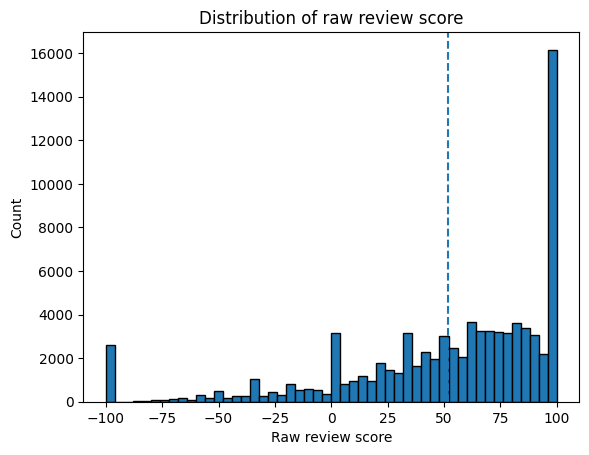

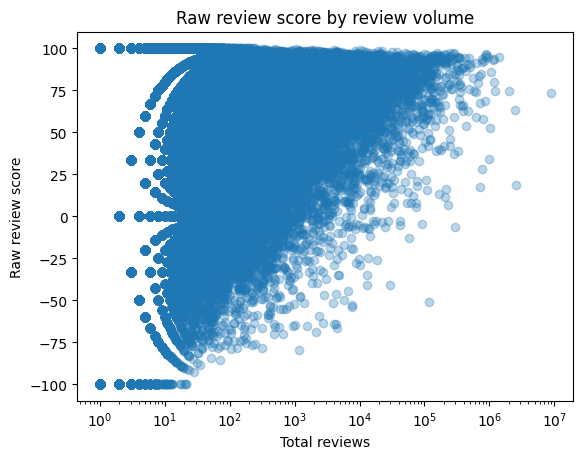

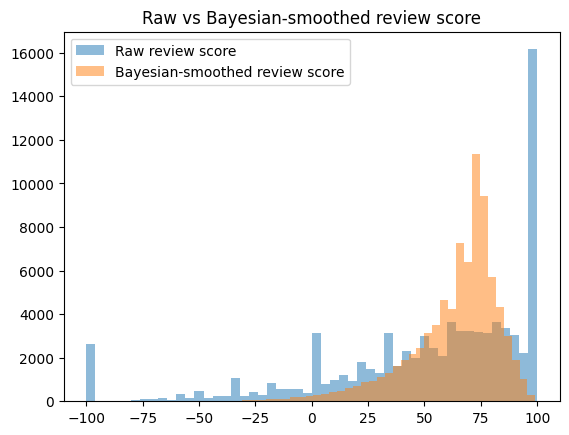

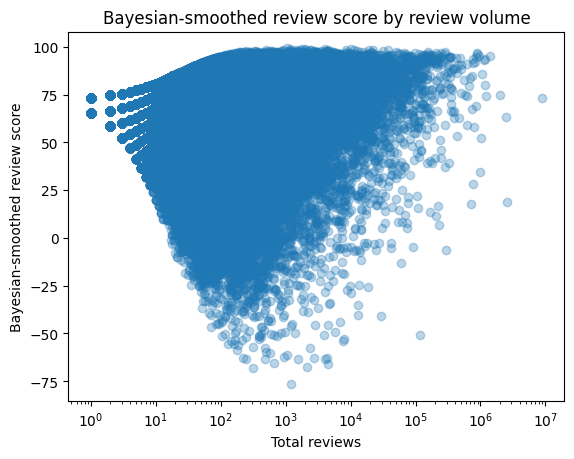

In [15]:
mean_review_score_raw = df["review_score_raw"].mean()

plt.figure()
plt.hist(df["review_score_raw"], bins=50, range=(-100, 100), edgecolor="black")
plt.axvline(mean_review_score_raw, linestyle="dashed")
plt.title("Distribution of raw review score")
plt.xlabel("Raw review score")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.scatter(df["total_reviews"], df["review_score_raw"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Total reviews")
plt.ylabel("Raw review score")
plt.title("Raw review score by review volume")
plt.show()

plt.figure()
plt.hist(df["review_score_raw"], bins=50, alpha=0.5, label="Raw review score")
plt.hist(df[target_col], bins=50, alpha=0.5, label="Bayesian-smoothed review score")
plt.legend()
plt.title("Raw vs Bayesian-smoothed review score")
plt.show()

plt.figure()
plt.scatter(df["total_reviews"], df[target_col], alpha=0.3)
plt.xscale("log")
plt.xlabel("Total reviews")
plt.ylabel("Bayesian-smoothed review score")
plt.title("Bayesian-smoothed review score by review volume")
plt.show()

In [16]:
num_features = [
    "price_original",
    "owners_mid",
    "release_year",
    "release_month",
    "Average playtime forever",
    "Median playtime forever",
    "Peak CCU"
]

X = df[num_features]
y = df[target_col]

print("Shape:", df.shape)
display(df.head())
print("\nFeatures:", list(X.columns))

Shape: (82766, 20)


,AppID,Name,Positive,Negative,Recommendations,price_original,owners_mid,Genres,release_year,release_month,Average playtime forever,Median playtime forever,Peak CCU,Categories,Tags,Developers,Publishers,total_reviews,review_score_raw,review_score_bayes
0,496350,Supipara - Chapter 1 Spring Has Come!,252,3,231,14.971429,10000.0,Adventure,2016,7,8,8,0,"Single-player,Steam Trading Cards,Steam Cloud,...","Adventure,Visual Novel,Anime,Cute",minori,MangaGamer,255,97.647059,95.551870
1,1034400,Mystery Solitaire The Black Raven,21,3,0,4.990000,10000.0,Casual,2019,5,0,0,0,"Single-player,Family Sharing","Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",Somer Games,8floor,24,75.000000,73.689784
5,1934300,Armored Brigade II,117,13,107,39.988889,10000.0,"Simulation,Strategy",2025,4,675,1253,8,"Single-player,Steam Workshop,Steam Cloud,Famil...","Simulation,Strategy,RTS,Wargame,Grand Strategy...",Veitikka Studios,Matrix Games,130,80.000000,78.845881
7,1157670,Hepta Beats,28,4,0,0.990000,10000.0,"Casual,Indie",2021,5,0,0,0,"Single-player,Steam Achievements,Full controll...","Precision Platformer,Rhythm,Music,Difficult,Ab...",Matheus Bigatão,Matheus Bigatão,32,75.000000,73.880361
8,1540330,MUMBA IV: Egypt Jewels,19,6,0,0.590000,10000.0,"Action,Casual,Indie,Strategy",2021,12,0,0,1,"Single-player,Steam Achievements,Full controll...","Casual,Action,Strategy,Puzzle,Match 3,Singlepl...",Airem,Airem,25,52.000000,61.737914



Features: ['price_original', 'owners_mid', 'release_year', 'release_month', 'Average playtime forever', 'Median playtime forever', 'Peak CCU']


## Train/test split

A single held-out test set is created and kept fixed throughout the notebook. Model selection and feature-set selection are performed on the training set using cross-validation, while the test set is used for final performance reporting and model comparison.

In [17]:
# ============================================================
# Single train/test split
# ============================================================

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)

df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

y_train = df_train[target_col]
y_test = df_test[target_col]

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Target train mean:", y_train.mean())
print("Target test mean:", y_test.mean())

Train shape: (66212, 20)
Test shape: (16554, 20)
Target train mean: 63.31320938684271
Target test mean: 62.87014192306597


In [18]:
X_train_num = df_train[num_features].copy()
X_test_num = df_test[num_features].copy()

## Numeric baseline models

The first modeling step uses only numerical features. A DummyRegressor is included as a naive baseline, while Ridge and Lasso provide regularized linear benchmarks. XGBoost is added as a non-linear tree ensemble model.

The models are tuned with cross-validation on the training set and then evaluated on the held-out test set.

In [19]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

def regression_metrics(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

models_num = {
    "Dummy mean": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean"))
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=10000))
    ]),

    "XGB": Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ))
])
}

param_grids_num = {
    "Dummy mean": {},

    "Ridge": {
        "model__alpha": [0.1, 1, 10, 100]
    },

    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1]
    },

    "XGB": {
        "model__n_estimators": [100, 300],
        "model__max_depth": [4, 6],
        "model__learning_rate": [0.05, 0.1]
    }
}

results_num = {}
best_models_num = {}

for name, model in models_num.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids_num[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        return_train_score=False
    )

    grid.fit(X_train_num, y_train)

    best_model = grid.best_estimator_
    best_models_num[name] = best_model

    y_pred = best_model.predict(X_test_num)
    metrics = regression_metrics(y_test, y_pred)

    results_num[name] = {
        "best_params": grid.best_params_,
        "cv_rmse": -grid.best_score_,
        "test_rmse": metrics["rmse"],
        "test_mae": metrics["mae"],
        "test_r2": metrics["r2"]
    }

    print("Best params:", grid.best_params_)
    print("CV RMSE:", round(-grid.best_score_, 3))
    print("Test RMSE:", round(metrics["rmse"], 3))
    print("Test MAE:", round(metrics["mae"], 3))
    print("Test R2:", round(metrics["r2"], 3))

numeric_comparison = pd.DataFrame(results_num).T
display(numeric_comparison)


Training Dummy mean...
Best params: {}
CV RMSE: 20.474
Test RMSE: 21.035
Test MAE: 15.585
Test R2: -0.0

Training Ridge...
Best params: {'model__alpha': 100}
CV RMSE: 19.609
Test RMSE: 20.277
Test MAE: 14.744
Test R2: 0.07

Training Lasso...
Best params: {'model__alpha': 0.01}
CV RMSE: 19.609
Test RMSE: 20.275
Test MAE: 14.744
Test R2: 0.071

Training XGB...
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300}
CV RMSE: 18.547
Test RMSE: 19.025
Test MAE: 13.893
Test R2: 0.182


,best_params,cv_rmse,test_rmse,test_mae,test_r2
Dummy mean,{},20.474307,21.035267,15.58515,-0.000444
Ridge,{'model__alpha': 100},19.609265,20.27679,14.744014,0.070402
Lasso,{'model__alpha': 0.01},19.608749,20.275328,14.744125,0.070536
XGB,"{'model__learning_rate': 0.1, 'model__max_dept...",18.547288,19.02465,13.893451,0.181667


### Numeric baseline results

The numerical-only XGBoost model outperforms the DummyRegressor and the regularized linear models, suggesting that the dataset contains non-linear relationships.

However, performance remains limited, indicating that numerical metadata and engagement indicators alone do not fully explain user reception. This motivates the addition of categorical metadata such as Genres, Categories and Tags.

In [20]:
# ============================================================
# 7. Model interpretation and predictive insights
# ============================================================

# Goal:
# After selecting XGBoost as the best-performing model,
# we analyze which variables drive predictions and where
# the model fails.

# 1. Feature importance
# 2. Permutation importance
# 3. Prediction error analysis
# 4. Predicted vs actual plot

,0
release_year,0.449240
Peak CCU,0.177234
price_original,0.111610
Average playtime forever,0.087408
owners_mid,0.084244
Median playtime forever,0.050377
release_month,0.039886


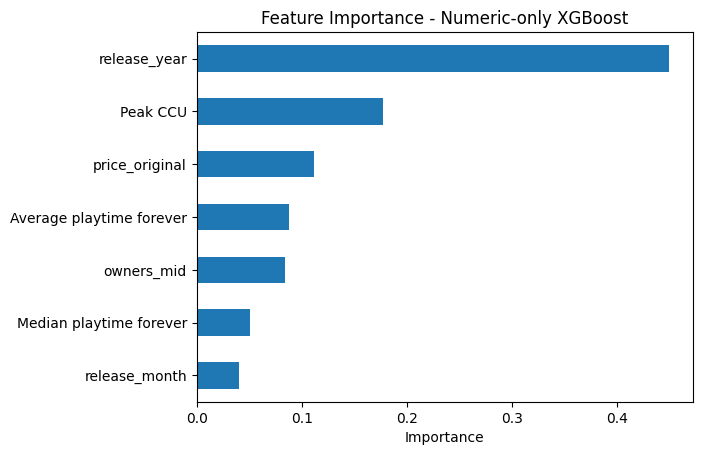

In [21]:
# ============================================================
# Numeric-only XGBoost interpretation
# ============================================================

xgb_numeric_pipeline = best_models_num["XGB"]
xgb_numeric_model = xgb_numeric_pipeline.named_steps["model"]

numeric_importances = pd.Series(
    xgb_numeric_model.feature_importances_,
    index=X_train_num.columns
).sort_values(ascending=False)

display(numeric_importances)

numeric_importances.sort_values().plot(kind="barh")
plt.title("Feature Importance - Numeric-only XGBoost")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

## Numeric-only model interpretation

After comparing the numerical baseline models, XGBoost is selected as the strongest numerical-only model.

This section analyzes which numerical variables contribute most to the model and where the model makes its largest prediction errors. The goal is to understand the limitations of numerical metadata before adding categorical features.

In [22]:
numeric_perm = permutation_importance(
    xgb_numeric_pipeline,
    X_test_num,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

numeric_perm_df = pd.DataFrame({
    "feature": X_test_num.columns,
    "importance": numeric_perm.importances_mean,
    "importance_std": numeric_perm.importances_std
}).sort_values("importance", ascending=False)

display(numeric_perm_df)

,feature,importance,importance_std
4,Average playtime forever,7.593152,0.085059
5,Median playtime forever,7.452801,0.064130
2,release_year,2.087524,0.042470
6,Peak CCU,1.358934,0.032995
0,price_original,0.959918,0.031690
1,owners_mid,0.178746,0.015495
3,release_month,0.041618,0.006032


### Numeric-only feature importance

Permutation importance provides a direct view of predictive contribution by measuring how much model performance worsens when each feature is randomly permuted.

In the numerical-only model, playtime-related variables and active popularity indicators are among the most informative predictors. This suggests that post-release engagement contains substantial signal about user reception.

Built-in XGBoost importance and permutation importance may rank features differently because they measure different notions of importance.

In [23]:
# ============================================================
# Numeric-only error analysis
# ============================================================

y_pred_num = xgb_numeric_pipeline.predict(X_test_num)

results_num_errors = X_test_num.copy()

results_num_errors.insert(
    0,
    "game_name",
    df.loc[X_test_num.index, "Name"]
)

results_num_errors["y_true"] = y_test
results_num_errors["y_pred"] = y_pred_num
results_num_errors["error"] = results_num_errors["y_true"] - results_num_errors["y_pred"]
results_num_errors["abs_error"] = results_num_errors["error"].abs()

display(
    results_num_errors
    .sort_values("abs_error", ascending=False)
    .head(20)
)

results_num_errors["y_true"].describe()

results_num_errors["y_true_bin"] = pd.qcut(
    results_num_errors["y_true"],
    q=5,
    duplicates="drop"
)

results_num_errors_by_bin = results_num_errors.groupby(
    "y_true_bin",
    observed=True
)[[
    "y_true",
    "y_pred",
    "error",
    "abs_error"
]].mean()

display(results_num_errors_by_bin)

,game_name,price_original,owners_mid,release_year,release_month,Average playtime forever,Median playtime forever,Peak CCU,y_true,y_pred,error,abs_error
47888,Command & Conquer™ 4 Tiberian Twilight,0.000000,150000.0,2010,3,371,71,8,-65.952414,60.715660,-126.668074,126.668074
66157,Airline Tycoon 2,9.950000,75000.0,2011,10,137,102,3,-60.333752,58.682190,-119.015942,119.015942
18536,Spacebase DF-9,9.933333,350000.0,2014,10,332,227,2,-63.074003,55.280453,-118.354456,118.354456
6864,Dead Matter,19.990000,10000.0,2023,9,0,0,0,-49.867655,63.935318,-113.802973,113.802973
24871,Feed the Cups,15.988889,750000.0,2024,2,2380,732,1161,-40.415432,72.789871,-113.205303,113.205303
103895,Sacred 3,14.960000,750000.0,2014,8,269,240,4,-45.754137,66.695084,-112.449220,112.449220
77126,Lost Daughter,4.990000,75000.0,2019,7,0,0,0,-51.059661,60.362518,-111.422179,111.422179
52909,STAR WARS™: Battlefront Classic Collection,35.000000,750000.0,2024,3,291,168,33,-53.794639,56.657074,-110.451713,110.451713
62076,Identity,29.990000,75000.0,2018,11,179,131,0,-67.499575,42.815601,-110.315176,110.315176
11704,World Ship Simulator,4.990000,75000.0,2016,11,90,50,2,-48.579313,60.155140,-108.734453,108.734453


,y_true,y_pred,error,abs_error
y_true_bin,,,,
"(-67.501, 49.216]",29.009627,57.041241,-28.031612,28.466496
"(49.216, 64.256]",57.610560,62.167133,-4.556574,8.120873
"(64.256, 73.014]",68.427561,64.278130,4.149433,6.266374
"(73.014, 78.049]",75.252268,66.524956,8.727310,8.766350
"(78.049, 98.309]",84.414902,66.299072,18.115832,18.134274


### Numeric-only error analysis

The numeric-only model tends to compress predictions toward the mean. It often overestimates poorly received games and underestimates highly received games.

This suggests that numerical metadata and engagement variables are informative for average cases, but insufficient to identify extreme user reception. Additional categorical metadata may help capture differences in game type, mechanics and user expectations.

## Categorical metadata: Genres and Categories

Steam games can belong to multiple genres and categories. These fields are therefore treated as multilabel categorical variables.

To avoid train-serving skew, the frequent labels are selected from the training set only and then applied consistently to both train and test data. This ensures that train and test matrices have the same feature space.

In [24]:
df.columns

Index(['AppID', 'Name', 'Positive', 'Negative', 'Recommendations',
       'price_original', 'owners_mid', 'Genres', 'release_year',
       'release_month', 'Average playtime forever', 'Median playtime forever',
       'Peak CCU', 'Categories', 'Tags', 'Developers', 'Publishers',
       'total_reviews', 'review_score_raw', 'review_score_bayes'],
      dtype='object')

In [25]:
df[["Genres", "Categories"]].head()

,Genres,Categories
0,Adventure,"Single-player,Steam Trading Cards,Steam Cloud,..."
1,Casual,"Single-player,Family Sharing"
5,"Simulation,Strategy","Single-player,Steam Workshop,Steam Cloud,Famil..."
7,"Casual,Indie","Single-player,Steam Achievements,Full controll..."
8,"Action,Casual,Indie,Strategy","Single-player,Steam Achievements,Full controll..."


In [26]:
# ============================================================
# Multilabel encoding fitted on train only
# ============================================================

def parse_multilabel_series(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.split(",")
        .apply(lambda items: [item.strip() for item in items if item.strip() != ""])
    )

def get_frequent_labels(series, min_frequency=100):
    parsed = parse_multilabel_series(series)

    counts = {}

    for labels in parsed:
        for label in labels:
            counts[label] = counts.get(label, 0) + 1

    frequent_labels = [
        label for label, count in counts.items()
        if count >= min_frequency
    ]

    return sorted(frequent_labels)

def encode_with_fixed_labels(series, labels, prefix):
    parsed = parse_multilabel_series(series).apply(set)

    encoded = pd.DataFrame(
        {
            f"{prefix}_{label}": parsed.apply(lambda x: int(label in x))
            for label in labels
        },
        index=series.index
    )

    return encoded

In [27]:
genre_labels = get_frequent_labels(
    df_train["Genres"],
    min_frequency=100
)

category_labels = get_frequent_labels(
    df_train["Categories"],
    min_frequency=100
)

print("Number of genre labels:", len(genre_labels))
print("Number of category labels:", len(category_labels))

Number of genre labels: 24
Number of category labels: 49


In [28]:
genres_train = encode_with_fixed_labels(
    df_train["Genres"],
    labels=genre_labels,
    prefix="genre"
)

genres_test = encode_with_fixed_labels(
    df_test["Genres"],
    labels=genre_labels,
    prefix="genre"
)

categories_train = encode_with_fixed_labels(
    df_train["Categories"],
    labels=category_labels,
    prefix="category"
)

categories_test = encode_with_fixed_labels(
    df_test["Categories"],
    labels=category_labels,
    prefix="category"
)

X_train_cat = pd.concat(
    [df_train[num_features], genres_train, categories_train],
    axis=1
)

X_test_cat = pd.concat(
    [df_test[num_features], genres_test, categories_test],
    axis=1
)

print("X_train_cat shape:", X_train_cat.shape)
print("X_test_cat shape:", X_test_cat.shape)

# Safety check: train and test must have exactly the same columns
assert list(X_train_cat.columns) == list(X_test_cat.columns)

X_train_cat shape: (66212, 80)
X_test_cat shape: (16554, 80)


In [29]:
# ============================================================
# XGBoost with numerical + Genres/Categories
# ============================================================

xgb_cat = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_cat.fit(X_train_cat, y_train)

y_pred_cat = xgb_cat.predict(X_test_cat)

cat_metrics = regression_metrics(y_test, y_pred_cat)

print("XGBoost + Genres/Categories")
print("RMSE:", cat_metrics["rmse"])
print("MAE:", cat_metrics["mae"])
print("R2:", cat_metrics["r2"])

XGBoost + Genres/Categories
RMSE: 17.973611204852638
MAE: 13.114785084817745
R2: 0.26958891005995667


In [30]:
# Recover the dictionary-based results if needed and define clear names for numeric-only baseline
# Note: We use the metrics specifically from the XGB model in the baseline dictionary

comparison_cat = pd.DataFrame([
    {
        "model": "Dummy mean",
        "rmse": results_num["Dummy mean"]["test_rmse"],
        "mae": results_num["Dummy mean"]["test_mae"],
        "r2": results_num["Dummy mean"]["test_r2"]
    },
    {
        "model": "XGB numeric only",
        "rmse": results_num["XGB"]["test_rmse"],
        "mae": results_num["XGB"]["test_mae"],
        "r2": results_num["XGB"]["test_r2"]
    },
    {
        "model": "XGB numeric + Genres/Categories",
        "rmse": cat_metrics["rmse"],
        "mae": cat_metrics["mae"],
        "r2": cat_metrics["r2"]
    }
]).sort_values("rmse").reset_index(drop=True)

display(comparison_cat)

,model,rmse,mae,r2
0,XGB numeric + Genres/Categories,17.973611,13.114785,0.269589
1,XGB numeric only,19.024650,13.893451,0.181667
2,Dummy mean,21.035267,15.585150,-0.000444


### Genres/Categories results

Adding Genres and Categories improves performance compared to the numerical-only XGBoost baseline, as shown by lower RMSE and MAE and higher R².

This suggests that categorical metadata provides additional predictive information about user reception that is not captured by price, release timing, ownership, playtime or concurrent users alone.

This is an intermediate held-out comparison. Final feature-set selection is performed later using training-set cross-validation.

In [31]:
results_cat = X_test_cat.copy()

if "Name" in df.columns:
    results_cat.insert(0, "game_name", df.loc[X_test_cat.index, "Name"])

results_cat["y_true"] = y_test
results_cat["y_pred"] = y_pred_cat
results_cat["error"] = results_cat["y_true"] - results_cat["y_pred"]
results_cat["abs_error"] = results_cat["error"].abs()

results_cat["y_true_bin"] = pd.qcut(
    results_cat["y_true"],
    q=5,
    duplicates="drop"
)

results_cat_by_bin = results_cat.groupby(
    "y_true_bin",
    observed=True
)[[
    "y_true",
    "y_pred",
    "error",
    "abs_error"
]].mean()

display(results_cat_by_bin)

,y_true,y_pred,error,abs_error
y_true_bin,,,,
"(-67.501, 49.216]",29.009627,54.800072,-25.790444,26.362522
"(49.216, 64.256]",57.610560,61.435623,-3.825061,8.117749
"(64.256, 73.014]",68.427561,64.489464,3.938096,6.509317
"(73.014, 78.049]",75.252268,67.087433,8.164838,8.469177
"(78.049, 98.309]",84.414902,68.141144,16.273758,16.355063


### Error analysis with Genres/Categories

The quantile-based error analysis compares average prediction errors across target bins. It helps evaluate whether categorical metadata reduces the regression-to-the-mean pattern.

The model still tends to overestimate low-review-score games and underestimate high-review-score games. However, the error pattern can be compared with the numeric-only model to assess whether categorical metadata improves predictions for extreme reception outcomes.

The exact values should be read from the table above rather than hardcoded, because they depend on the train/test split and model configuration.

In [32]:
feat_imp_cat = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": xgb_cat.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp_cat.head(30)

,feature,importance
19,genre_Massively Multiplayer,0.071650
2,release_year,0.067829
52,category_Online Co-op,0.049316
68,category_Steam Cloud,0.048821
43,category_In-App Purchases,0.048526
24,genre_Simulation,0.043956
41,category_Full controller support,0.036927
6,Peak CCU,0.030698
11,genre_Casual,0.022211
60,category_Remote Play on Tablet,0.021912


In [33]:
perm_cat = permutation_importance(
    xgb_cat,
    X_test_cat,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_cat_df = pd.DataFrame({
    "feature": X_test_cat.columns,
    "importance": perm_cat.importances_mean
}).sort_values("importance", ascending=False)

perm_cat_df.head(30)

,feature,importance
2,release_year,2.339942
6,Peak CCU,1.020406
0,price_original,0.491735
24,genre_Simulation,0.379954
4,Average playtime forever,0.236777
68,category_Steam Cloud,0.163234
41,category_Full controller support,0.157766
7,genre_Action,0.147867
18,genre_Indie,0.107374
51,category_Multi-player,0.106797


### Interpretation of categorical feature importance

The XGBoost model with Genres and Categories improves over the numerical-only baseline, showing that categorical metadata contains additional predictive signal.

Several categorical features contribute meaningfully, suggesting that user reception is associated not only with engagement and popularity indicators, but also with the type of game and supported gameplay/platform features.

Built-in XGBoost feature importance and permutation importance can differ because they measure different aspects of model behavior. Built-in importance reflects tree split usage, while permutation importance measures the performance drop caused by disrupting a feature.

In [34]:
# ============================================================
# Descriptive analysis of selected categorical features
# Using labels selected from the training set
# ============================================================

genres_all = encode_with_fixed_labels(
    df["Genres"],
    labels=genre_labels,
    prefix="genre"
)

categories_all = encode_with_fixed_labels(
    df["Categories"],
    labels=category_labels,
    prefix="category"
)

analysis_df = pd.concat(
    [df.copy(), genres_all, categories_all],
    axis=1
)

selected_categorical_features = [
    "genre_Simulation",
    "genre_Action",
    "genre_Indie",
    "category_Steam Cloud",
    "category_Full controller support",
    "category_Multi-player"
]

for col in selected_categorical_features:
    if col in analysis_df.columns:
        print("\n", col)
        print(analysis_df.groupby(col)[target_col].agg(["count", "mean", "median"]))
    else:
        print(f"\n{col} not available after frequency filtering.")


 genre_Simulation
                  count       mean     median
genre_Simulation                             
0                 65777  64.409363  69.512349
1                 16989  58.637463  64.498728

 genre_Action
              count       mean     median
genre_Action                             
0             47402  63.971958  69.015550
1             35364  62.222819  67.823841

 genre_Indie
             count       mean     median
genre_Indie                             
0            23469  61.664914  66.964413
1            59297  63.841892  69.015550

 category_Steam Cloud
                      count       mean     median
category_Steam Cloud                             
0                     59297  61.838867  67.458417
1                     23469  66.725776  71.984321

 category_Full controller support
                                  count       mean     median
category_Full controller support                             
0                                 62716  61.904790  67

### Descriptive analysis of selected categorical features

The descriptive analysis compares average target values for selected categorical indicators. This helps interpret whether certain genres or categories are associated with different user reception patterns.

These comparisons are descriptive and should not be interpreted causally. A higher or lower average review score for a category does not imply that the category itself causes better or worse reception.

## Tags extension

Tags provide a more granular description of games than Genres or Categories. They may capture gameplay mechanics, themes, difficulty, atmosphere and audience expectations.

As with Genres and Categories, frequent Tags are selected from the training set only and then applied to both train and test data to keep the feature space consistent.

In [35]:
# ============================================================
# Optional extension: Tags
# ============================================================

tag_labels = get_frequent_labels(
    df_train["Tags"],
    min_frequency=200
)

print("Number of tag labels:", len(tag_labels))

tags_train = encode_with_fixed_labels(
    df_train["Tags"],
    labels=tag_labels,
    prefix="tag"
)

tags_test = encode_with_fixed_labels(
    df_test["Tags"],
    labels=tag_labels,
    prefix="tag"
)

X_train_cat_tags = pd.concat(
    [df_train[num_features], genres_train, categories_train, tags_train],
    axis=1
)

X_test_cat_tags = pd.concat(
    [df_test[num_features], genres_test, categories_test, tags_test],
    axis=1
)

print("X_train_cat_tags shape:", X_train_cat_tags.shape)
print("X_test_cat_tags shape:", X_test_cat_tags.shape)

assert list(X_train_cat_tags.columns) == list(X_test_cat_tags.columns)

Number of tag labels: 341
X_train_cat_tags shape: (66212, 421)
X_test_cat_tags shape: (16554, 421)


## Feature block selection with cross-validation

The Genres/Categories feature set is compared with the Genres/Categories/Tags feature set using cross-validation on the training set only.

This avoids selecting the final feature set based on the held-out test set. The test set is reserved for final performance reporting.

In [36]:
# ============================================================
# Feature block selection using training-set cross-validation
# ============================================================

feature_blocks = {
    "numerical + Genres/Categories": X_train_cat,
    "numerical + Genres/Categories/Tags": X_train_cat_tags
}

feature_block_rows = []

cv_feature_blocks = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for feature_set_name, X_block_train in feature_blocks.items():
    print(f"\nEvaluating feature block: {feature_set_name}")

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1
    )

    cv_results = cross_validate(
        estimator=model,
        X=X_block_train,
        y=y_train,
        cv=cv_feature_blocks,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )

    feature_block_rows.append({
        "feature_set": feature_set_name,
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_mae_std": cv_results["test_mae"].std(),
        "cv_r2_mean": cv_results["test_r2"].mean(),
        "cv_r2_std": cv_results["test_r2"].std()
    })

feature_block_comparison = (
    pd.DataFrame(feature_block_rows)
    .sort_values("cv_rmse_mean")
    .reset_index(drop=True)
)

display(feature_block_comparison)


Evaluating feature block: numerical + Genres/Categories

Evaluating feature block: numerical + Genres/Categories/Tags


,feature_set,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,numerical + Genres/Categories/Tags,16.985387,0.039056,12.450220,0.018501,0.311747,0.002719
1,numerical + Genres/Categories,17.588884,0.039886,12.949155,0.030119,0.261967,0.003611


In [37]:
# ============================================================
# Select final feature set based on training-set CV
# ============================================================

best_feature_set = feature_block_comparison.iloc[0]["feature_set"]

if best_feature_set == "numerical + Genres/Categories/Tags":
    X_train_final_features = X_train_cat_tags
    X_test_final_features = X_test_cat_tags
else:
    X_train_final_features = X_train_cat
    X_test_final_features = X_test_cat

final_feature_set_name = best_feature_set

print("Selected final feature set:", final_feature_set_name)
print("Final train shape:", X_train_final_features.shape)
print("Final test shape:", X_test_final_features.shape)

assert list(X_train_final_features.columns) == list(X_test_final_features.columns)

Selected final feature set: numerical + Genres/Categories/Tags
Final train shape: (66212, 421)
Final test shape: (16554, 421)


## Final model tuning

After selecting the final feature block using training-set cross-validation, XGBoost hyperparameters are tuned with GridSearchCV.

The tuning grid is intentionally compact to keep the experiment computationally reasonable while still testing model complexity and learning-rate choices.

In [38]:
# ============================================================
# Final tuning: XGBoost with numerical + Genres/Categories/Tags
# Tuning is performed on the training set only.
# ============================================================

param_grid_final = {
    "n_estimators": [300],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_final = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_final,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=False,
    verbose=2
)

grid_final.fit(X_train_final_features, y_train)

xgb_final = grid_final.best_estimator_

print("Best final params:")
print(grid_final.best_params_)

print("Best CV RMSE:")
print(-grid_final.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best final params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE:
16.985386582192877


In [39]:
# ============================================================
# Final test evaluation
# ============================================================

y_pred_final = xgb_final.predict(X_test_final_features)

final_metrics = regression_metrics(y_test, y_pred_final)

print("Final tuned XGBoost")
print("Feature set:", final_feature_set_name)
print("RMSE:", final_metrics["rmse"])
print("MAE:", final_metrics["mae"])
print("R2:", final_metrics["r2"])

Final tuned XGBoost
Feature set: numerical + Genres/Categories/Tags
RMSE: 17.378939597193725
MAE: 12.608069305989138
R2: 0.31712184505088803


Tags were added as an additional multilabel feature block and compared against the Genres/Categories feature set using training-set cross-validation.

Since the Tags feature block achieved better cross-validated RMSE, MAE and R², the final model was tuned using numerical features, Genres, Categories and Tags.

Final performance was then evaluated once on the held-out test set.

This does not imply that Tags causally determine user reception. Rather, Tags contain predictive information about game type, mechanics, themes and audience expectations.

## Final comparison

The final comparison summarizes the progression from a naive baseline to the tuned XGBoost model using numerical, categorical and tag-based features.

The final selected model is evaluated on the held-out test set.

In [40]:
# ============================================================
# Final comparison table
# ============================================================

final_comparison = pd.DataFrame([
    {
        "model": "Dummy mean",
        "rmse": results_num["Dummy mean"]["test_rmse"],
        "mae": results_num["Dummy mean"]["test_mae"],
        "r2": results_num["Dummy mean"]["test_r2"]
    },
    {
        "model": "XGB numeric only",
        "rmse": results_num["XGB"]["test_rmse"],
        "mae": results_num["XGB"]["test_mae"],
        "r2": results_num["XGB"]["test_r2"]
    },
    {
        "model": "XGB numeric + Genres/Categories",
        "rmse": cat_metrics["rmse"],
        "mae": cat_metrics["mae"],
        "r2": cat_metrics["r2"]
    },
    {
        "model": f"XGB final tuned ({final_feature_set_name})",
        "rmse": final_metrics["rmse"],
        "mae": final_metrics["mae"],
        "r2": final_metrics["r2"]
    }
]).sort_values("rmse").reset_index(drop=True)

display(final_comparison)

final_model_row = final_comparison[
    final_comparison["model"].str.startswith("XGB final tuned")
].iloc[0]

print("Final selected model:", final_model_row["model"])
print("Final RMSE:", round(final_model_row["rmse"], 3))
print("Final MAE:", round(final_model_row["mae"], 3))
print("Final R2:", round(final_model_row["r2"], 3))

,model,rmse,mae,r2
0,XGB final tuned (numerical + Genres/Categories...,17.378940,12.608069,0.317122
1,XGB numeric + Genres/Categories,17.973611,13.114785,0.269589
2,XGB numeric only,19.024650,13.893451,0.181667
3,Dummy mean,21.035267,15.585150,-0.000444


Final selected model: XGB final tuned (numerical + Genres/Categories/Tags)
Final RMSE: 17.379
Final MAE: 12.608
Final R2: 0.317


## Final error analysis

The final error analysis examines where the tuned model makes its largest mistakes and whether prediction errors differ across the target distribution.

This is useful because aggregate metrics such as RMSE and MAE do not show whether the model systematically overestimates or underestimates certain types of games.

In [41]:
# ============================================================
# Final error analysis
# ============================================================

final_results = df_test[[
    "Name",
    "Genres",
    "Categories",
    "Tags",
    "Positive",
    "Negative",
    "total_reviews"
]].copy()

final_results["y_true"] = y_test
final_results["y_pred"] = y_pred_final
final_results["error"] = final_results["y_true"] - final_results["y_pred"]
final_results["abs_error"] = final_results["error"].abs()

display(
    final_results
    .sort_values("abs_error", ascending=False)
    .head(20)
)

final_results["y_true_bin"] = pd.qcut(
    final_results["y_true"],
    q=5,
    duplicates="drop"
)

final_error_by_bin = final_results.groupby(
    "y_true_bin",
    observed=True
)[[
    "y_true",
    "y_pred",
    "error",
    "abs_error"
]].mean()

display(final_error_by_bin)

,Name,Genres,Categories,Tags,Positive,Negative,total_reviews,y_true,y_pred,error,abs_error
24871,Feed the Cups,"Casual,Indie,Simulation,Early Access","Single-player,Multi-player,Co-op,Online Co-op,...","Early Access,Cute,Simulation,Cooking,Online Co...",3922,9286,13208,-40.415432,82.473877,-122.889309,122.889309
47888,Command & Conquer™ 4 Tiberian Twilight,"Adventure,Strategy","Single-player,Multi-player,Steam Workshop,Stea...","Level Editor,Strategy,Adventure,RTS,Multiplaye...",758,3788,4546,-65.952414,54.862350,-120.814765,120.814765
52909,STAR WARS™: Battlefront Classic Collection,Action,"Single-player,Multi-player,PvP,Online PvP,LAN ...","Action,Space,Sci-fi,FPS,Shooter,Third-Person S...",1748,5881,7629,-53.794639,66.553596,-120.348236,120.348236
28041,VEGAS Pro 18 Edit Steam Edition,"Audio Production,Video Production",Missing,"Video Production,Audio Production,Singleplayer",478,1859,2337,-57.812110,58.753448,-116.565559,116.565559
77126,Lost Daughter,"Action,Adventure,Indie","Single-player,Family Sharing","Action,Indie,Adventure,Open World",81,308,389,-51.059661,57.656822,-108.716483,108.716483
18536,Spacebase DF-9,"Indie,Simulation,Strategy","Single-player,Steam Trading Cards,Steam Cloud,...","Simulation,Space,Base-Building,Sci-fi,Strategy...",780,3529,4309,-63.074003,43.459820,-106.533823,106.533823
89556,Vickinachi,"Action,Adventure,RPG","Single-player,Steam Achievements,Steam Cloud,F...","RPG,Adventure,Action,RPGMaker,Indie,Superhero,...",35,177,212,-53.347150,48.253147,-101.600297,101.600297
66241,Uriel's Chasm,"Adventure,Casual,Indie","Single-player,Steam Trading Cards,Family Sharing","Indie,Casual,Psychological Horror,Adventure,Pi...",491,2219,2710,-62.618580,38.383045,-101.001626,101.001626
80621,校长模拟器,"Casual,RPG,Simulation,Strategy","Single-player,Steam Achievements,Family Sharing","Simulation,Management,Building,Political Sim,R...",13,72,85,-39.227594,61.408329,-100.635923,100.635923
61980,FlatOut 3: Chaos & Destruction,Racing,"Single-player,Multi-player,Co-op,Partial Contr...","Psychological Horror,Combat Racing,Racing,Auto...",719,3269,3988,-63.160454,36.020088,-99.180542,99.180542


,y_true,y_pred,error,abs_error
y_true_bin,,,,
"(-67.501, 49.216]",29.009627,53.756176,-24.746550,25.288117
"(49.216, 64.256]",57.610560,60.723740,-3.113178,7.690362
"(64.256, 73.014]",68.427561,64.298836,4.128726,6.943447
"(73.014, 78.049]",75.252268,67.508339,7.743926,8.273164
"(78.049, 98.309]",84.414902,69.514381,14.900519,15.048966


## Final model interpretation

Feature importance and permutation importance are used to interpret which variables contribute most to the final model.

Permutation importance is computed on a 5,000-row subset of the test set for computational efficiency. The results should be interpreted as predictive importance, not causal effects.

,feature,importance
83,tag_2D,0.032989
164,tag_Cute,0.025178
2,release_year,0.020788
68,category_Steam Cloud,0.018178
254,tag_Massively Multiplayer,0.017191
215,tag_Great Soundtrack,0.016778
19,genre_Massively Multiplayer,0.016364
299,tag_Pixel Graphics,0.015986
348,tag_Simulation,0.014603
207,tag_Funny,0.014361


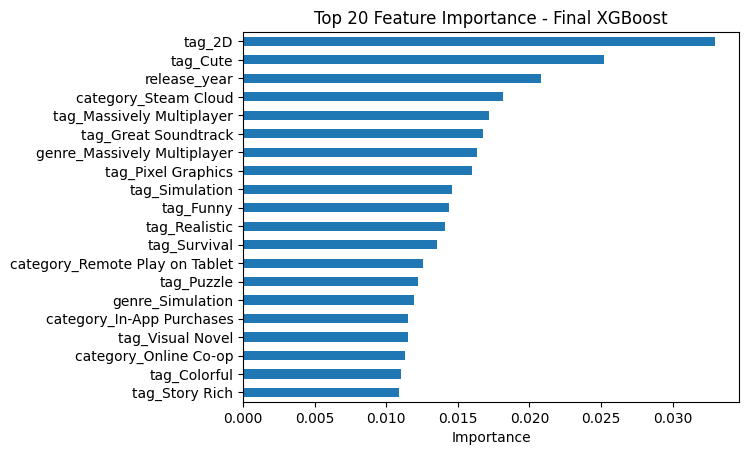

In [42]:
# ============================================================
# Final feature importance
# ============================================================

final_feat_imp = pd.DataFrame({
    "feature": X_train_final_features.columns,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=False)

display(final_feat_imp.head(30))

final_feat_imp.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.title("Top 20 Feature Importance - Final XGBoost")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

,feature,importance,importance_std
2,release_year,2.365460,0.137656
6,Peak CCU,1.102976,0.062001
4,Average playtime forever,0.381904,0.045602
0,price_original,0.265115,0.006090
83,tag_2D,0.148787,0.019883
68,category_Steam Cloud,0.138204,0.020953
1,owners_mid,0.135611,0.010653
348,tag_Simulation,0.117223,0.014982
43,category_In-App Purchases,0.092754,0.008423
312,tag_Puzzle,0.092587,0.010756


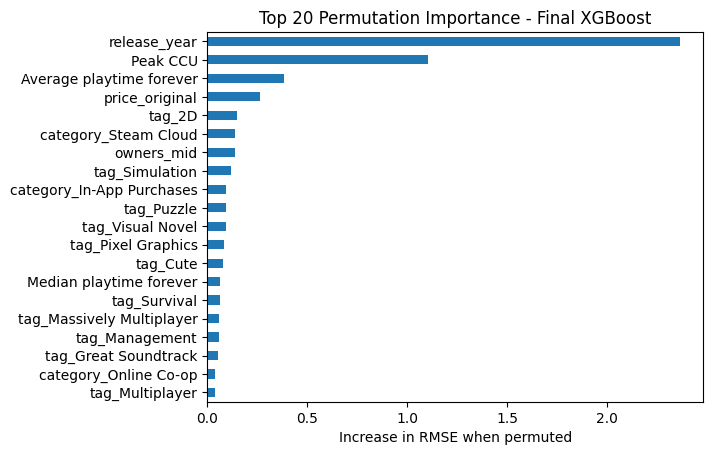

In [43]:
# ============================================================
# Final permutation importance
# Computed on a test subset for efficiency
# ============================================================

perm_sample_idx = X_test_final_features.sample(
    n=min(5000, len(X_test_final_features)),
    random_state=42
).index

perm_final = permutation_importance(
    xgb_final,
    X_test_final_features.loc[perm_sample_idx],
    y_test.loc[perm_sample_idx],
    scoring="neg_root_mean_squared_error",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_final_df = pd.DataFrame({
    "feature": X_test_final_features.columns,
    "importance": perm_final.importances_mean,
    "importance_std": perm_final.importances_std
}).sort_values("importance", ascending=False)

display(perm_final_df.head(30))

perm_final_df.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.title("Top 20 Permutation Importance - Final XGBoost")
plt.xlabel("Increase in RMSE when permuted")
plt.ylabel("")
plt.show()

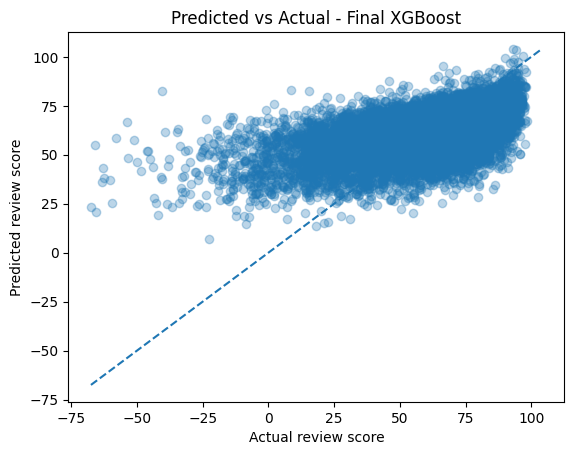

In [44]:
plt.figure()
plt.scatter(final_results["y_true"], final_results["y_pred"], alpha=0.3)
plt.xlabel("Actual review score")
plt.ylabel("Predicted review score")
plt.title("Predicted vs Actual - Final XGBoost")

min_value = min(final_results["y_true"].min(), final_results["y_pred"].min())
max_value = max(final_results["y_true"].max(), final_results["y_pred"].max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="dashed")
plt.show()

## Final conclusion

The final model predicts a Bayesian-smoothed Steam review reception score using post-release metadata, engagement indicators and multilabel categorical metadata.

The main result is that adding multilabel categorical metadata, especially Tags, improves predictive performance compared to a numerical-only model. Tags provide more granular information about gameplay style, themes, mechanics and user expectations, which helps the model explain differences in Steam user reception.

Final tuning selected the same hyperparameter configuration used in the initial Tags model, indicating that this configuration was the best one among the tested grid.

However, the model should be interpreted as a post-release reception model, not as a pre-release success forecasting model, because several predictors such as owners, playtime and Peak CCU are observed after release.

Error analysis shows that the model still tends to regress toward the mean: poorly received games are often overestimated, while highly received games are underestimated. This suggests that extreme user sentiment is difficult to capture without richer qualitative data such as review text, bugs, update history, developer reputation or community sentiment.

The results are predictive and descriptive, not causal.